# **Klasifikasi Kategori ISPU DKI Jakarta**
## Menggunakan Random Forest, XGBoost, dan SVM
### Metodologi: CRISP-DM

---

Notebook ini mengikuti tahapan CRISP-DM:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

---
## **0. Instalasi & Import Library**

In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Model Selection
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Algoritma
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay
)

# Deployment (simpan model)
import joblib

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Semua library berhasil diimpor.')

Semua library berhasil diimpor.


---
<a name="2"></a>
## 1. Business Understanding

### 1. Deskripsi Masalah dan Tujuan Penelitian

Kualitas udara di DKI Jakarta menjadi perhatian serius karena dampak langsung terhadap kesehatan masyarakat. Indeks Standar Pencemar Udara (ISPU) digunakan pemerintah untuk mengkategorikan kualitas udara harian berdasarkan enam parameter polutan: PM10, PM2.5, SO₂, CO, O₃, dan NO₂.

**Permasalahan:**
- Proses kategorisasi manual memerlukan waktu dan rentan terhadap inkonsistensi.
- Diperlukan model prediktif yang akurat untuk mengklasifikasikan kategori ISPU secara otomatis.

**Tujuan:**
1. Membangun model klasifikasi ISPU menggunakan tiga algoritma: **Random Forest**, **XGBoost**, dan **SVM**.
2. Membandingkan performa ketiga model berdasarkan metrik evaluasi (accuracy, precision, recall, F1-score).
3. Menentukan model terbaik untuk klasifikasi kualitas udara di DKI Jakarta.

### 2. Definisi Target Variabel

Target variabel adalah **kategori** ISPU yang terdiri dari:
| Kategori | Rentang ISPU |
|---|---|
| BAIK | 0 – 50 |
| SEDANG | 51 – 100 |
| TIDAK SEHAT | 101 – 200 |


---
## **2. Data Understanding**

### 2.1 Memuat Dataset

In [ ]:
# Upload file di Google Colab
from google.colab import files
uploaded = files.upload()

Saving Data_ISPU.csv to Data_ISPU (1).csv


In [ ]:
# Memuat dataset
df_raw = pd.read_csv('Data_ISPU.csv', sep=';')

print(f'Jumlah baris  : {df_raw.shape[0]}')
print(f'Jumlah kolom  : {df_raw.shape[1]}')
print(f'Nama kolom    : {list(df_raw.columns)}')
print()
df_raw.head(10)

Jumlah baris  : 3350
Jumlah kolom  : 13
Nama kolom    : ['periode_data', 'bulan', 'tanggal', 'stasiun', 'pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max', 'parameter_pencemar_kritis', 'kategori']



,periode_data,bulan,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202401,1,21,DKI3 Jagakarsa,51.0,65.0,45.0,9.0,8.0,79.0,79.0,NaN,SEDANG
1,202401,1,22,DKI3 Jagakarsa,27.0,34.0,45.0,5.0,8.0,56.0,56.0,NaN,SEDANG
2,202401,1,23,DKI3 Jagakarsa,NaN,52.0,46.0,6.0,9.0,51.0,52.0,PM25,SEDANG
3,202401,1,24,DKI3 Jagakarsa,46.0,65.0,46.0,8.0,9.0,38.0,65.0,PM25,SEDANG
4,202401,1,25,DKI3 Jagakarsa,37.0,55.0,47.0,7.0,11.0,28.0,55.0,PM25,SEDANG
5,202401,1,26,DKI3 Jagakarsa,43.0,62.0,50.0,7.0,15.0,14.0,62.0,PM25,SEDANG
6,202401,1,27,DKI3 Jagakarsa,40.0,52.0,48.0,8.0,12.0,10.0,52.0,PM25,SEDANG
7,202401,1,28,DKI3 Jagakarsa,40.0,62.0,48.0,12.0,12.0,18.0,62.0,PM25,SEDANG
8,202401,1,29,DKI3 Jagakarsa,33.0,44.0,47.0,14.0,12.0,24.0,47.0,SO2,BAIK
9,202401,1,30,DKI3 Jagakarsa,58.0,46.0,48.0,22.0,12.0,33.0,58.0,PM10,SEDANG


### 2.2 Eksplorasi Struktur Data

In [ ]:
# Informasi tipe data dan non-null count
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3350 entries, 0 to 3349
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   periode_data               3350 non-null   int64  
 1   bulan                      3350 non-null   int64  
 2   tanggal                    3350 non-null   int64  
 3   stasiun                    3350 non-null   object 
 4   pm_sepuluh                 3100 non-null   float64
 5   pm_duakomalima             3290 non-null   float64
 6   sulfur_dioksida            3295 non-null   float64
 7   karbon_monoksida           3302 non-null   float64
 8   ozon                       3305 non-null   float64
 9   nitrogen_dioksida          3282 non-null   float64
 10  max                        3342 non-null   float64
 11  parameter_pencemar_kritis  3287 non-null   object 
 12  kategori                   3349 non-null   object 
dtypes: float64(7), int64(3), object(3)
memory usage:

In [ ]:
# Statistik ringkas
df_raw.describe()

,periode_data,bulan,tanggal,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max
count,3350.000000,3350.000000,3350.000000,3100.000000,3290.000000,3295.000000,3302.000000,3305.000000,3282.000000,3342.000000
mean,202451.470746,6.067761,15.742388,49.629677,72.238602,36.034901,15.278619,24.066868,27.266606,73.861460
std,49.407721,3.238671,8.808854,16.303816,23.085151,16.080692,6.816273,12.956883,16.534151,21.143591
min,202401.000000,1.000000,1.000000,5.000000,10.000000,3.000000,2.000000,2.000000,1.000000,0.000000
25%,202406.000000,3.000000,8.000000,38.000000,57.000000,24.000000,10.000000,15.000000,15.000000,59.000000
50%,202412.000000,6.000000,16.000000,52.000000,74.000000,32.000000,14.000000,22.000000,24.000000,74.000000
75%,202505.000000,9.000000,23.000000,60.000000,88.000000,53.000000,20.000000,29.000000,37.000000,88.000000
max,202510.000000,12.000000,31.000000,187.000000,157.000000,112.000000,70.000000,115.000000,187.000000,187.000000


In [ ]:
# Cek nilai unik pada kolom kategori (target)
print('Nilai unik pada kolom kategori:')
print(df_raw['kategori'].value_counts(dropna=False))

Nilai unik pada kolom kategori:
kategori
SEDANG            2604
BAIK               386
TIDAK SEHAT        340
TIDAK ADA DATA      19
NaN                  1
Name: count, dtype: int64


In [ ]:
# Cek stasiun unik
print('Stasiun unik:')
for s in df_raw['stasiun'].unique():
    print(f'  - "{s}"')

Stasiun unik:
  - "DKI3 Jagakarsa"
  - "DKI1 Bunderan HI"
  - "DKI2 Kelapa Gading"
  - "DKI4 Lubang Buaya"
  - "DKI1 Bundaran Hotel Indonesia (HI)"
  - "DKI5 Kebon Jeruk Jakarta Barat"
  - "DKI5 Kebon Jeruk"
  - "DKI1 Bundaran Hotel Indonesia HI"


### 2.3 EDA (Exploratory Data Analysis)

#### 2.3.1 Statistik Deskriptif

In [ ]:
# Kolom fitur polutan
fitur_polutan = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida',
                 'karbon_monoksida', 'ozon', 'nitrogen_dioksida']

# Konversi ke numerik terlebih dahulu untuk statistik
df_eda = df_raw.copy()
for col in fitur_polutan:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

# Statistik deskriptif lengkap
stats = df_eda[fitur_polutan].describe().T
stats['median'] = df_eda[fitur_polutan].median()
stats['skew'] = df_eda[fitur_polutan].skew()
stats['kurtosis'] = df_eda[fitur_polutan].kurtosis()
stats

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
pm_sepuluh,3100.0,49.629677,16.303816,5.0,38.0,52.0,60.0,187.0,52.0,0.117997,2.110287
pm_duakomalima,3290.0,72.238602,23.085151,10.0,57.0,74.0,88.0,157.0,74.0,-0.229667,-0.034092
sulfur_dioksida,3295.0,36.034901,16.080692,3.0,24.0,32.0,53.0,112.0,32.0,0.219345,-1.052386
karbon_monoksida,3302.0,15.278619,6.816273,2.0,10.0,14.0,20.0,70.0,14.0,1.000282,3.012211
ozon,3305.0,24.066868,12.956883,2.0,15.0,22.0,29.0,115.0,22.0,1.420434,2.882157
nitrogen_dioksida,3282.0,27.266606,16.534151,1.0,15.0,24.0,37.0,187.0,24.0,1.207253,3.528467


#### 2.3.2 Distribusi Kelas Target (Cek Imbalance)

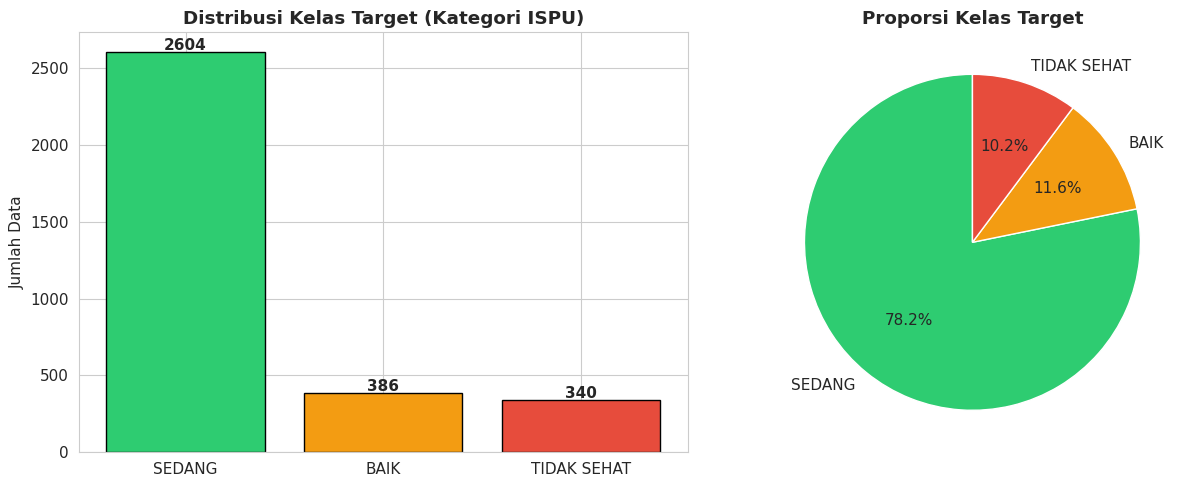


Rasio imbalance:
  SEDANG: 2604 (78.2%)
  BAIK: 386 (11.6%)
  TIDAK SEHAT: 340 (10.2%)


In [ ]:
# Filter hanya kategori valid
kategori_valid = df_eda[df_eda['kategori'].isin(['BAIK', 'SEDANG', 'TIDAK SEHAT'])]
counts = kategori_valid['kategori'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Kelas Target (Kategori ISPU)', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRasio imbalance:')
for cat in counts.index:
    print(f'  {cat}: {counts[cat]} ({counts[cat]/counts.sum()*100:.1f}%)')

#### 2.3.3 Visualisasi Distribusi Fitur (Histogram)

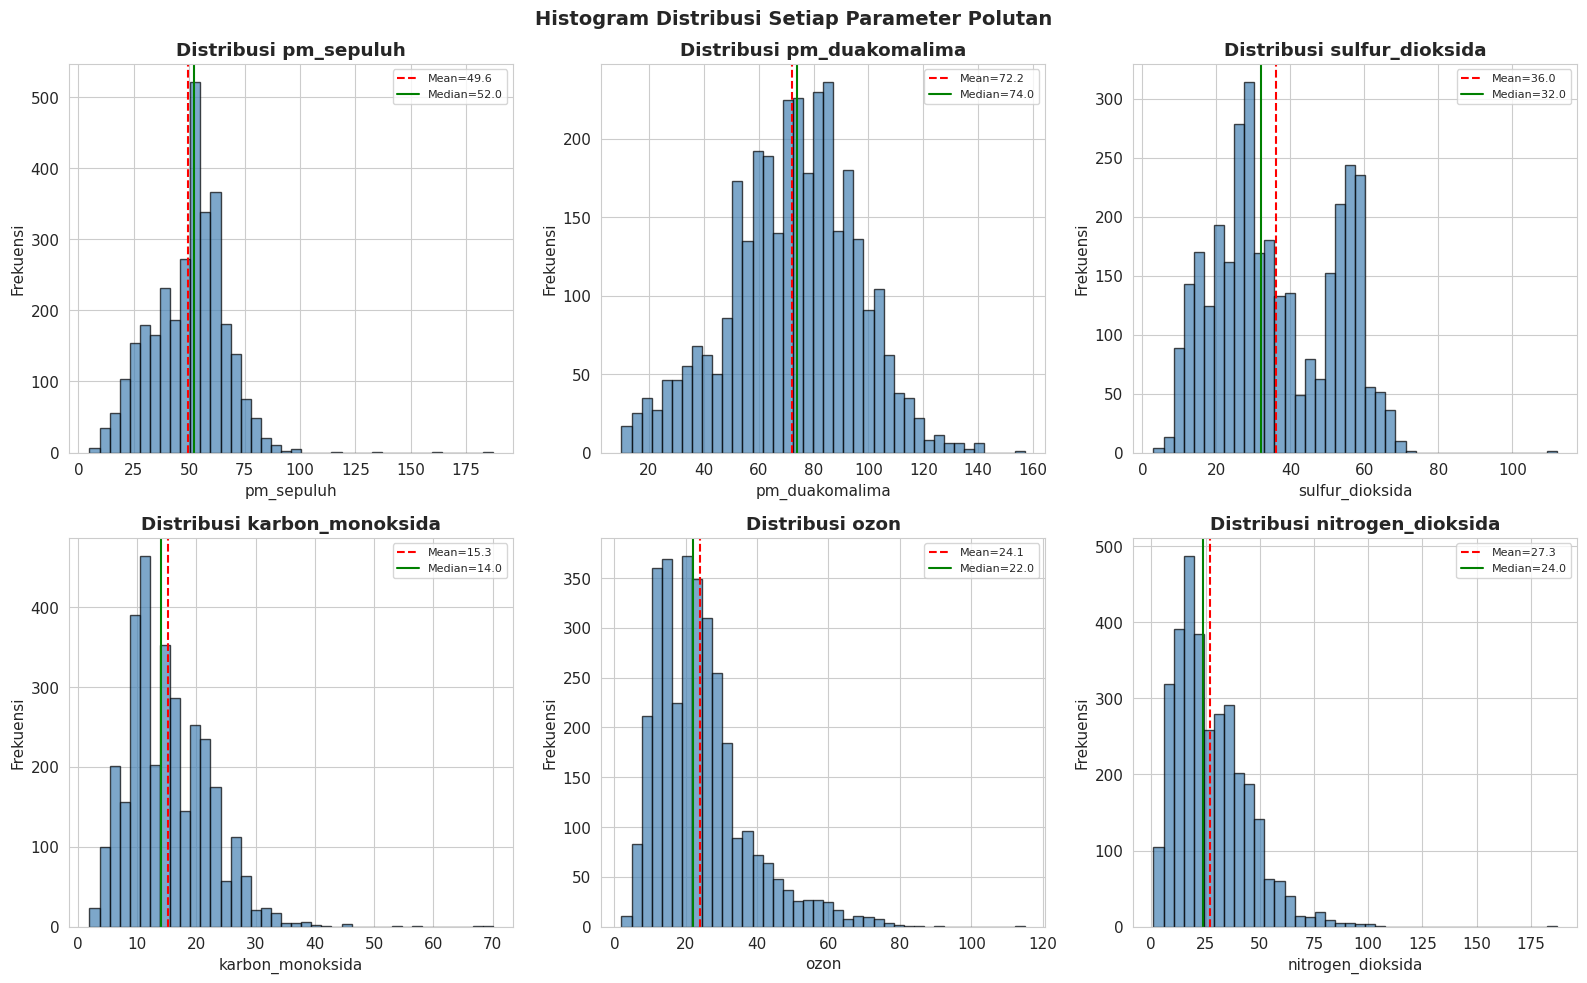

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_polutan):
    axes[i].hist(df_eda[col].dropna(), bins=40, color='steelblue',
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    # Tambah garis mean & median
    mean_val = df_eda[col].mean()
    med_val = df_eda[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.1f}')
    axes[i].axvline(med_val, color='green', linestyle='-', label=f'Median={med_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Histogram Distribusi Setiap Parameter Polutan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.3.4 Boxplot (Deteksi Outlier)

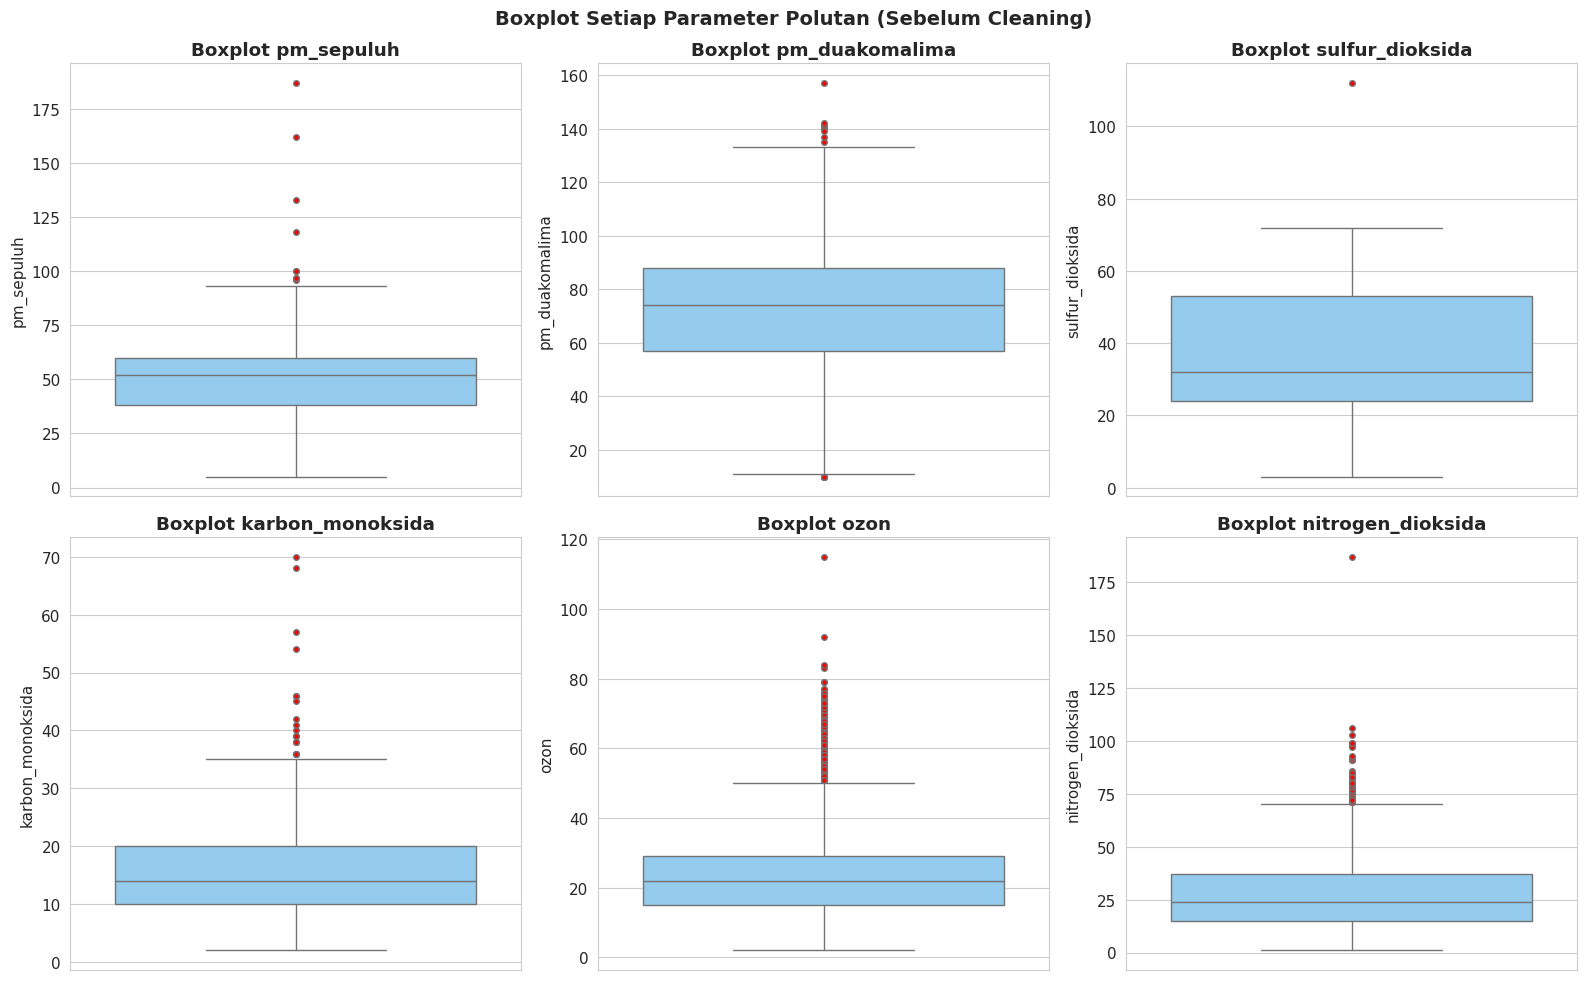

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_polutan):
    sns.boxplot(y=df_eda[col], ax=axes[i], color='lightskyblue',
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    axes[i].set_title(f'Boxplot {col}', fontweight='bold')

plt.suptitle('Boxplot Setiap Parameter Polutan (Sebelum Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.3.5 Missing Values & Data Anomali

Missing Values pada Fitur Polutan:
                   Jumlah Missing  Persentase (%)
pm_sepuluh                    250            7.46
pm_duakomalima                 60            1.79
sulfur_dioksida                55            1.64
karbon_monoksida               48            1.43
ozon                           45            1.34
nitrogen_dioksida              68            2.03


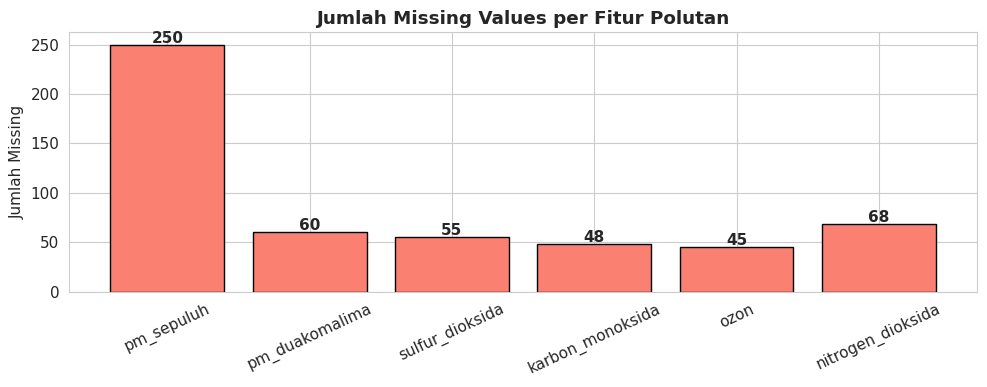

In [ ]:
# Hitung missing values
missing = df_eda[fitur_polutan].isnull().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print('Missing Values pada Fitur Polutan:')
print(missing_df)

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(missing.index, missing.values, color='salmon', edgecolor='black')
ax.set_title('Jumlah Missing Values per Fitur Polutan', fontweight='bold')
ax.set_ylabel('Jumlah Missing')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontweight='bold')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

#### 2.3.6 Heatmap Korelasi Antar Fitur

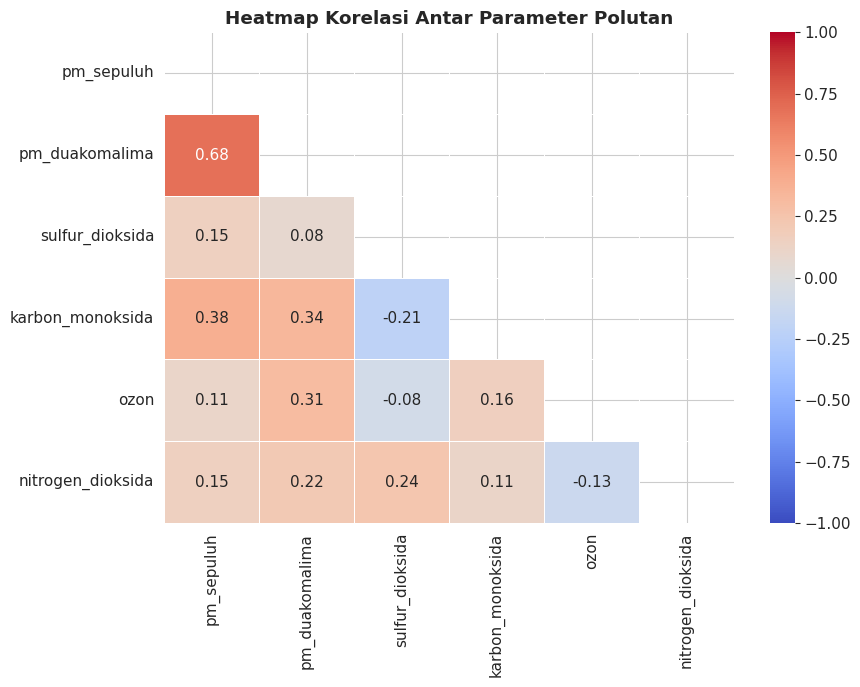

In [ ]:
plt.figure(figsize=(9, 7))
corr = df_eda[fitur_polutan].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Parameter Polutan', fontweight='bold')
plt.tight_layout()
plt.show()

---
## **3. Data Preparation**

### 3.1 Data Cleaning

In [ ]:
df = df_raw.copy()
print(f'Data awal: {df.shape[0]} baris')

# --- 3.1.1 Hapus baris dengan kategori "TIDAK ADA DATA" atau NaN ---
df = df[df['kategori'].isin(['BAIK', 'SEDANG', 'TIDAK SEHAT'])].copy()
print(f'Setelah hapus TIDAK ADA DATA & NaN kategori: {df.shape[0]} baris')

# --- 3.1.2 Standarisasi nama stasiun (duplikat varian) ---
stasiun_mapping = {
    'DKI1 Bundaran Hotel Indonesia (HI)': 'DKI1 Bunderan HI',
    'DKI1 Bundaran Hotel Indonesia HI': 'DKI1 Bunderan HI',
}
df['stasiun'] = df['stasiun'].replace(stasiun_mapping)
print(f'Stasiun setelah standarisasi: {df["stasiun"].nunique()} stasiun unik')
print(df['stasiun'].value_counts())

# --- 3.1.3 Konversi kolom polutan ke numerik ---
for col in fitur_polutan:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'\nTipe data setelah konversi:')
print(df[fitur_polutan].dtypes)

Data awal: 3350 baris
Setelah hapus TIDAK ADA DATA & NaN kategori: 3330 baris
Stasiun setelah standarisasi: 6 stasiun unik
stasiun
DKI1 Bunderan HI                  669
DKI2 Kelapa Gading                667
DKI3 Jagakarsa                    666
DKI4 Lubang Buaya                 660
DKI5 Kebon Jeruk                  518
DKI5 Kebon Jeruk Jakarta Barat    150
Name: count, dtype: int64

Tipe data setelah konversi:
pm_sepuluh           float64
pm_duakomalima       float64
sulfur_dioksida      float64
karbon_monoksida     float64
ozon                 float64
nitrogen_dioksida    float64
dtype: object


### 3.2 Imputasi Missing Values (Median)

In [ ]:
print('Missing values SEBELUM imputasi:')
print(df[fitur_polutan].isnull().sum())

# Imputasi dengan median per kolom
for col in fitur_polutan:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    if n_missing > 0:
        print(f'  {col}: {n_missing} nilai diisi dengan median = {median_val}')

print('\nMissing values SESUDAH imputasi:')
print(df[fitur_polutan].isnull().sum())

Missing values SEBELUM imputasi:
pm_sepuluh           230
pm_duakomalima        40
sulfur_dioksida       35
karbon_monoksida      28
ozon                  25
nitrogen_dioksida     48
dtype: int64
  pm_sepuluh: 230 nilai diisi dengan median = 52.0
  pm_duakomalima: 40 nilai diisi dengan median = 74.0
  sulfur_dioksida: 35 nilai diisi dengan median = 32.0
  karbon_monoksida: 28 nilai diisi dengan median = 14.0
  ozon: 25 nilai diisi dengan median = 22.0
  nitrogen_dioksida: 48 nilai diisi dengan median = 24.0

Missing values SESUDAH imputasi:
pm_sepuluh           0
pm_duakomalima       0
sulfur_dioksida      0
karbon_monoksida     0
ozon                 0
nitrogen_dioksida    0
dtype: int64


### 3.3 Hapus Outlier (Metode IQR)

In [ ]:
print(f'Data sebelum penghapusan outlier: {df.shape[0]} baris')

# Metode IQR: hapus baris yang memiliki outlier pada SALAH SATU fitur
mask_inlier = pd.Series([True] * len(df), index=df.index)

outlier_info = []
for col in fitur_polutan:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (df[col] < lower) | (df[col] > upper)
    n_out = outliers.sum()
    outlier_info.append({'Fitur': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                         'Batas Bawah': lower, 'Batas Atas': upper,
                         'Jumlah Outlier': n_out})
    mask_inlier = mask_inlier & ~outliers

outlier_df = pd.DataFrame(outlier_info)
print('\nDetail IQR per fitur:')
display(outlier_df)

df = df[mask_inlier].copy()
print(f'\nData setelah penghapusan outlier: {df.shape[0]} baris')
print(f'Baris yang dihapus: {mask_inlier.shape[0] - df.shape[0]}')

Data sebelum penghapusan outlier: 3330 baris

Detail IQR per fitur:


,Fitur,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,pm_sepuluh,39.0,60.0,21.0,7.5,91.5,13
1,pm_duakomalima,58.0,88.0,30.0,13.0,133.0,23
2,sulfur_dioksida,24.0,53.0,29.0,-19.5,96.5,1
3,karbon_monoksida,10.0,20.0,10.0,-5.0,35.0,20
4,ozon,15.0,29.0,14.0,-6.0,50.0,169
5,nitrogen_dioksida,15.0,37.0,22.0,-18.0,70.0,57



Data setelah penghapusan outlier: 3057 baris
Baris yang dihapus: 273


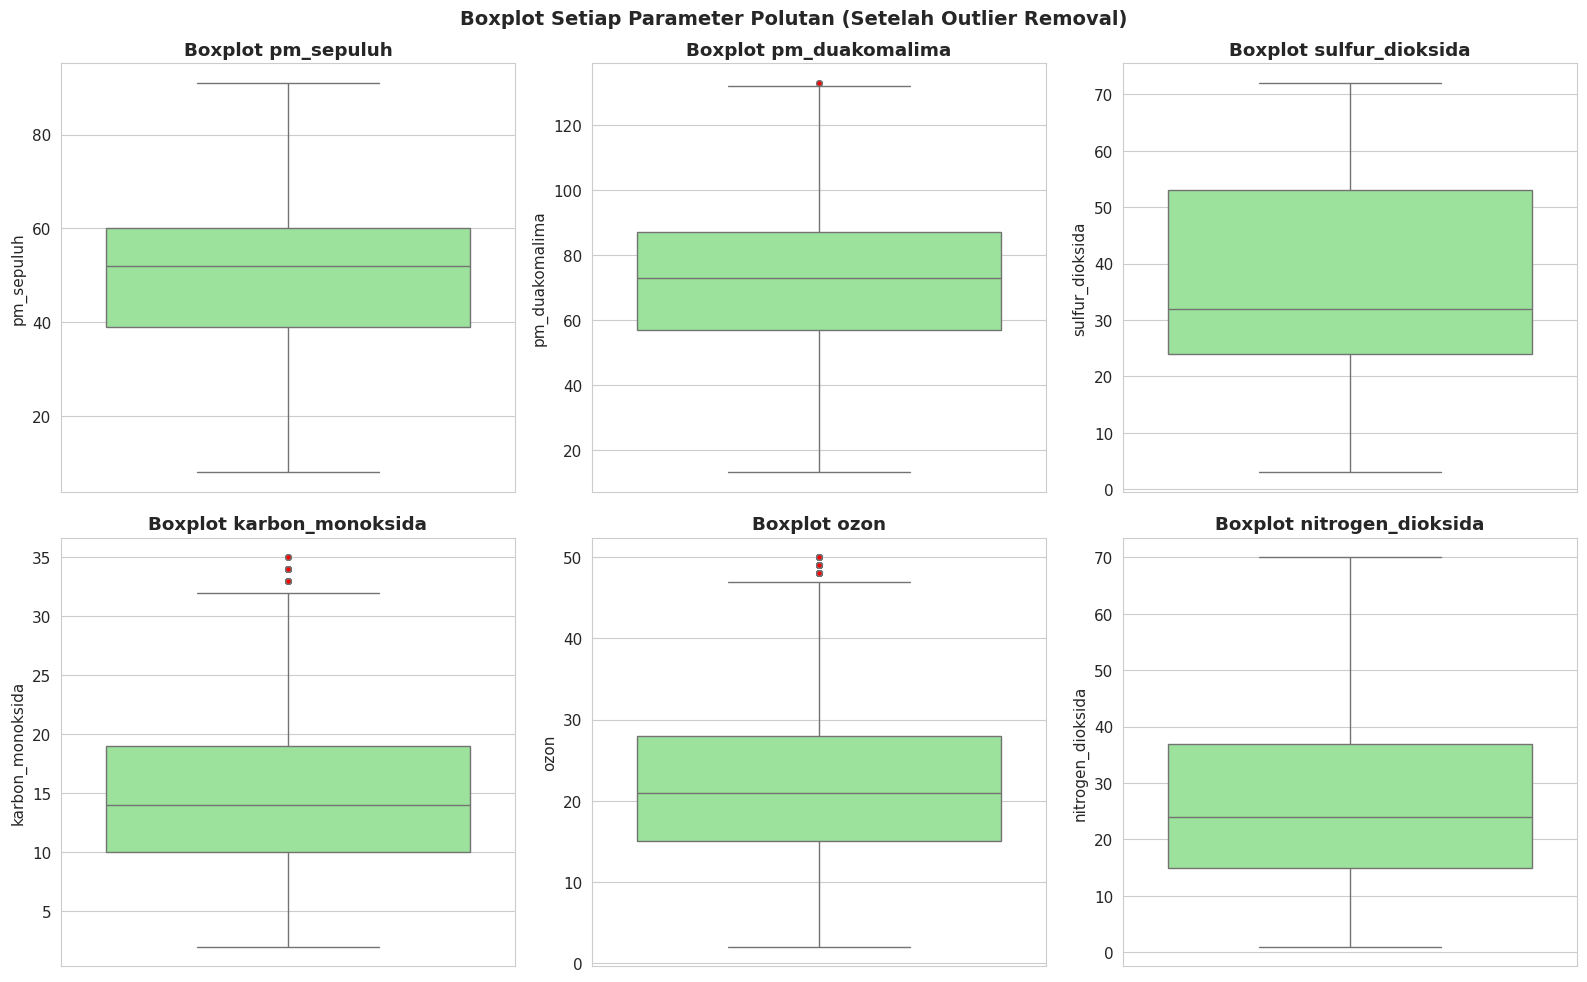

In [ ]:
# Boxplot setelah outlier removal
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen',
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    axes[i].set_title(f'Boxplot {col}', fontweight='bold')

plt.suptitle('Boxplot Setiap Parameter Polutan (Setelah Outlier Removal)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Seleksi Fitur & Pemisahan Target

In [ ]:
# Fitur (X): 6 parameter polutan
X = df[fitur_polutan].copy()

# Target (y): kategori ISPU
y = df['kategori'].copy()

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nDistribusi target setelah cleaning:')
print(y.value_counts())

Shape X: (3057, 6)
Shape y: (3057,)

Distribusi target setelah cleaning:
kategori
SEDANG         2414
BAIK            380
TIDAK SEHAT     263
Name: count, dtype: int64


### 3.5 Label Encoding

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Mapping Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} → {i}')

print(f'\nDistribusi y_encoded: {np.bincount(y_encoded)}')

Mapping Label Encoding:
  BAIK → 0
  SEDANG → 1
  TIDAK SEHAT → 2

Distribusi y_encoded: [ 380 2414  263]


### 3.6 Split Data (80:20 Stratified)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)')

print(f'\nDistribusi kelas di Training: {np.bincount(y_train)}')
print(f'Distribusi kelas di Testing : {np.bincount(y_test)}')

Training set : 2445 baris (80%)
Testing set  : 612 baris (20%)

Distribusi kelas di Training: [ 304 1931  210]
Distribusi kelas di Testing : [ 76 483  53]


### 3.7 Feature Scaling (Z-Score, khusus SVM)

In [ ]:
# SVM sensitif terhadap skala fitur, jadi perlu StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling (Z-score) diterapkan untuk SVM.')
print(f'Mean setelah scaling (train): {X_train_scaled.mean(axis=0).round(4)}')
print(f'Std setelah scaling (train) : {X_train_scaled.std(axis=0).round(4)}')

Feature scaling (Z-score) diterapkan untuk SVM.
Mean setelah scaling (train): [ 0. -0.  0. -0.  0.  0.]
Std setelah scaling (train) : [1. 1. 1. 1. 1. 1.]


---
## **4. Modeling**

### 4.1 Baseline Models (Sebelum Tuning)

In [ ]:
# ============================================================
# BASELINE MODELS
# ============================================================
baseline_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss',
                             use_label_encoder=False),
    'SVM': SVC(random_state=42, kernel='rbf')
}

baseline_results = {}

for name, model in baseline_models.items():
    # SVM pakai data scaled, RF dan XGBoost pakai data asli
    if name == 'SVM':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    baseline_results[name] = acc
    print(f'{name} Baseline Accuracy: {acc:.4f}')

print('\n--- Baseline selesai ---')

Random Forest Baseline Accuracy: 0.9706
XGBoost Baseline Accuracy: 0.9788
SVM Baseline Accuracy: 0.9412

--- Baseline selesai ---


### 4.2 Hyperparameter Tuning (GridSearchCV + Stratified K-Fold CV, k=5)

In [ ]:
# Stratified K-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 4.2.1 RANDOM FOREST - Hyperparameter Tuning
# ============================================================
print('='*60)
print('TUNING: Random Forest')
print('='*60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f'\nBest Parameters: {rf_grid.best_params_}')
print(f'Best CV Accuracy: {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_

TUNING: Random Forest
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 0.9808


In [ ]:
# ============================================================
# 4.2.2 XGBOOST - Hyperparameter Tuning
# ============================================================
print('='*60)
print('TUNING: XGBoost')
print('='*60)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss',
                  use_label_encoder=False),
    param_grid=xgb_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

print(f'\nBest Parameters: {xgb_grid.best_params_}')
print(f'Best CV Accuracy: {xgb_grid.best_score_:.4f}')

xgb_best = xgb_grid.best_estimator_

TUNING: XGBoost
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV Accuracy: 0.9845


In [ ]:
# ============================================================
# 4.2.3 SVM - Hyperparameter Tuning
# ============================================================
print('='*60)
print('TUNING: SVM')
print('='*60)

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'poly']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_scaled, y_train)

print(f'\nBest Parameters: {svm_grid.best_params_}')
print(f'Best CV Accuracy: {svm_grid.best_score_:.4f}')

svm_best = svm_grid.best_estimator_

TUNING: SVM
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Accuracy: 0.9538


---
## **5. Evaluation**

### 5.1 Confusion Matrix

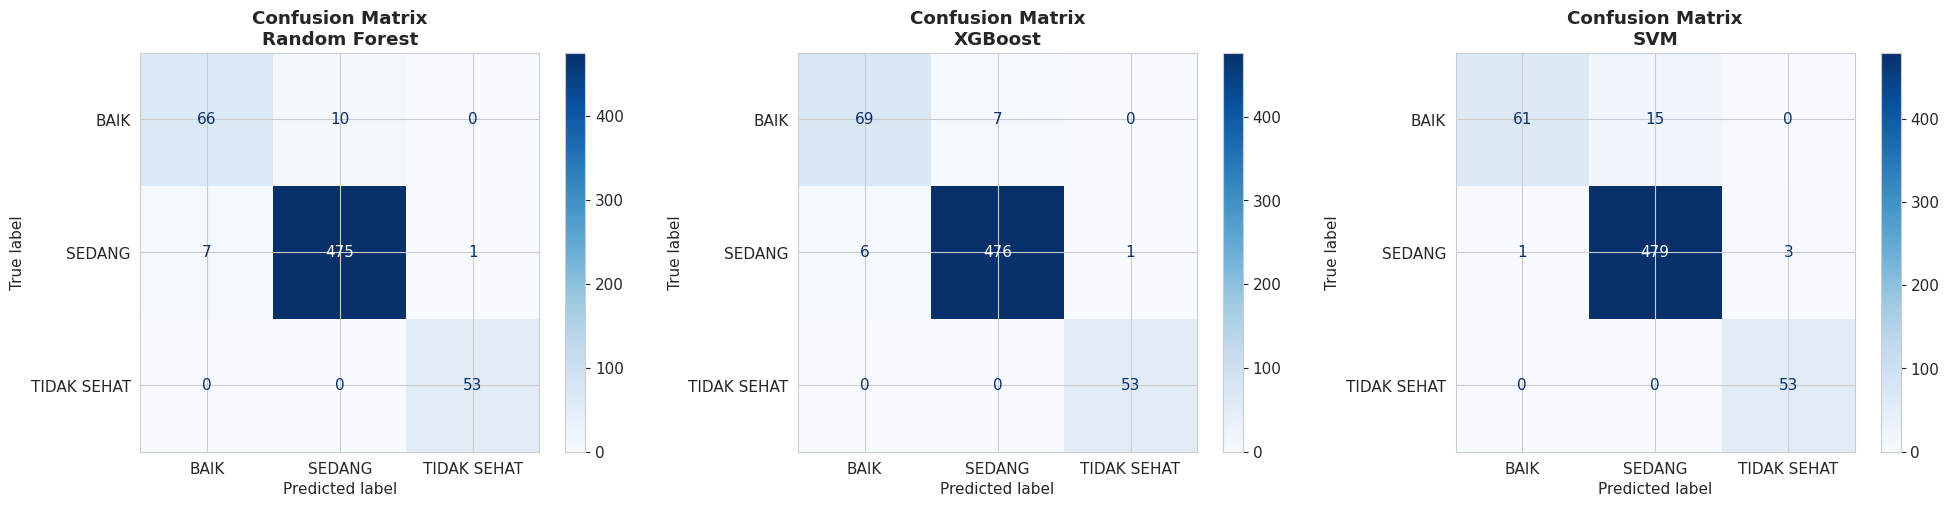

In [ ]:
# Prediksi dengan model terbaik
models_best = {
    'Random Forest': (rf_best, X_test),
    'XGBoost': (xgb_best, X_test),
    'SVM': (svm_best, X_test_scaled)
}

predictions = {}
for name, (model, X_data) in models_best.items():
    predictions[name] = model.predict(X_data)

# Plot Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix\n{name}', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Classification Report (Precision, Recall, F1-Score)

In [ ]:
for name, y_pred in predictions.items():
    print('='*60)
    print(f'CLASSIFICATION REPORT: {name}')
    print('='*60)
    print(classification_report(y_test, y_pred,
                                target_names=le.classes_, digits=4))
    print()

CLASSIFICATION REPORT: Random Forest
              precision    recall  f1-score   support

        BAIK     0.9041    0.8684    0.8859        76
      SEDANG     0.9794    0.9834    0.9814       483
 TIDAK SEHAT     0.9815    1.0000    0.9907        53

    accuracy                         0.9706       612
   macro avg     0.9550    0.9506    0.9527       612
weighted avg     0.9702    0.9706    0.9703       612


CLASSIFICATION REPORT: XGBoost
              precision    recall  f1-score   support

        BAIK     0.9200    0.9079    0.9139        76
      SEDANG     0.9855    0.9855    0.9855       483
 TIDAK SEHAT     0.9815    1.0000    0.9907        53

    accuracy                         0.9771       612
   macro avg     0.9623    0.9645    0.9634       612
weighted avg     0.9770    0.9771    0.9771       612


CLASSIFICATION REPORT: SVM
              precision    recall  f1-score   support

        BAIK     0.9839    0.8026    0.8841        76
      SEDANG     0.9696    0.991

### 5.3 Cross-Validation (Akurasi Rata-Rata & Standar Deviasi)

Stratified 5-Fold Cross-Validation Results:
--------------------------------------------------
Random Forest:
  Fold scores  : [0.9877 0.9714 0.9816 0.9836 0.9796]
  Mean Accuracy: 0.9808
  Std Deviation: 0.0054

XGBoost:
  Fold scores  : [0.9836 0.9816 0.9836 0.9857 0.9877]
  Mean Accuracy: 0.9845
  Std Deviation: 0.0021

SVM:
  Fold scores  : [0.9509 0.955  0.9571 0.9468 0.9591]
  Mean Accuracy: 0.9538
  Std Deviation: 0.0044



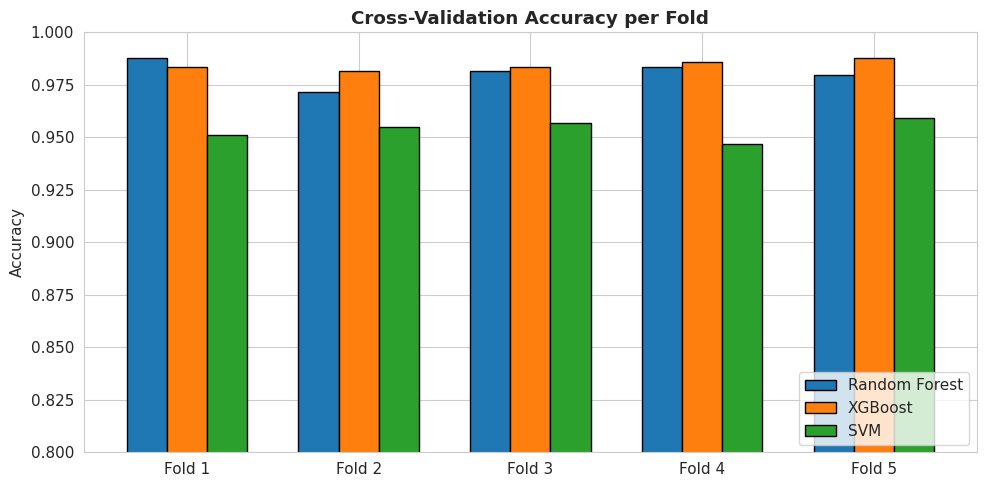

In [ ]:
cv_results = {}

# RF & XGBoost: data asli; SVM: data scaled
cv_configs = {
    'Random Forest': (rf_best, X_train),
    'XGBoost': (xgb_best, X_train),
    'SVM': (svm_best, X_train_scaled)
}

print('Stratified 5-Fold Cross-Validation Results:')
print('-'*50)

for name, (model, X_data) in cv_configs.items():
    scores = cross_val_score(model, X_data, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Fold scores  : {scores.round(4)}')
    print(f'  Mean Accuracy: {scores.mean():.4f}')
    print(f'  Std Deviation: {scores.std():.4f}')
    print()

# Visualisasi CV
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = pd.DataFrame(cv_results)
cv_data.index = [f'Fold {i+1}' for i in range(5)]

cv_data.plot(kind='bar', ax=ax, edgecolor='black', width=0.7)
ax.set_title('Cross-Validation Accuracy per Fold', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.4 Feature Importance

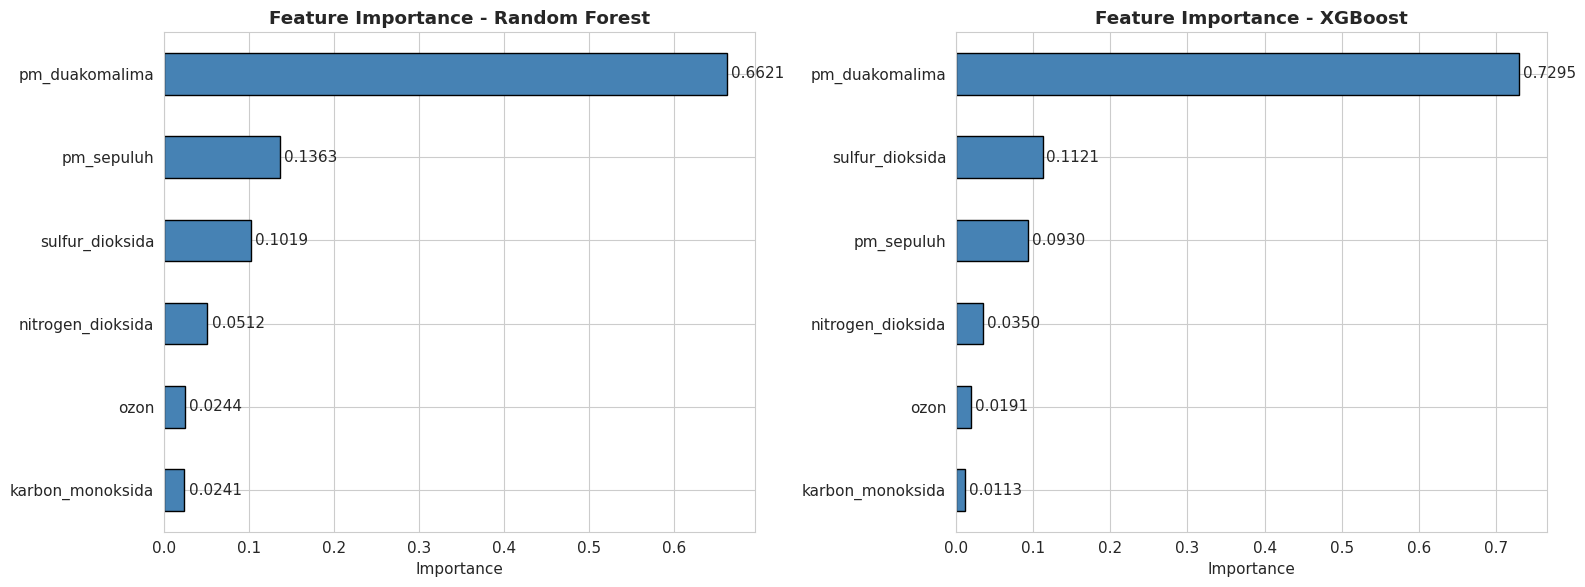


Tabel Feature Importance:


,Fitur,RF Importance,XGB Importance
1,pm_duakomalima,0.662088,0.729514
0,pm_sepuluh,0.136284,0.093025
2,sulfur_dioksida,0.101872,0.112139
5,nitrogen_dioksida,0.051191,0.035007
4,ozon,0.024444,0.019052
3,karbon_monoksida,0.024120,0.011264


In [ ]:
# Feature Importance dari Random Forest dan XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, model) in enumerate([('Random Forest', rf_best),
                                     ('XGBoost', xgb_best)]):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=fitur_polutan).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Feature Importance - {name}', fontweight='bold')
    axes[i].set_xlabel('Importance')

    # Tampilkan nilai
    for j, (val, label) in enumerate(zip(feat_imp.values, feat_imp.index)):
        axes[i].text(val + 0.005, j, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

# Tabel feature importance
fi_table = pd.DataFrame({
    'Fitur': fitur_polutan,
    'RF Importance': rf_best.feature_importances_,
    'XGB Importance': xgb_best.feature_importances_
}).sort_values('RF Importance', ascending=False)
print('\nTabel Feature Importance:')
display(fi_table)

### 5.5 Perbandingan Performa Model & Pemilihan Model Terbaik

In [ ]:
# Rangkuman perbandingan
comparison = []

for name, y_pred in predictions.items():
    report = classification_report(y_test, y_pred, output_dict=True, digits=4)
    cv_scores = cv_results[name]

    comparison.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1-Score': report['macro avg']['f1-score'],
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.round(4)

print('='*80)
print('PERBANDINGAN PERFORMA MODEL')
print('='*80)
display(comparison_df)

# Tentukan model terbaik berdasarkan Test Accuracy
best_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_accuracy = comparison_df.loc[best_idx, 'Test Accuracy']

print(f'\n*** MODEL TERBAIK: {best_model_name} ***')
print(f'    Test Accuracy   : {best_accuracy:.4f}')
print(f'    CV Mean Accuracy: {comparison_df.loc[best_idx, "CV Mean Accuracy"]:.4f}')
print(f'    CV Std          : {comparison_df.loc[best_idx, "CV Std"]:.4f}')

PERBANDINGAN PERFORMA MODEL


,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-Score,CV Mean Accuracy,CV Std
0,Random Forest,0.9706,0.9550,0.9506,0.9527,0.9808,0.0054
1,XGBoost,0.9771,0.9623,0.9645,0.9634,0.9845,0.0021
2,SVM,0.9690,0.9666,0.9315,0.9457,0.9538,0.0044



*** MODEL TERBAIK: XGBoost ***
    Test Accuracy   : 0.9771
    CV Mean Accuracy: 0.9845
    CV Std          : 0.0021


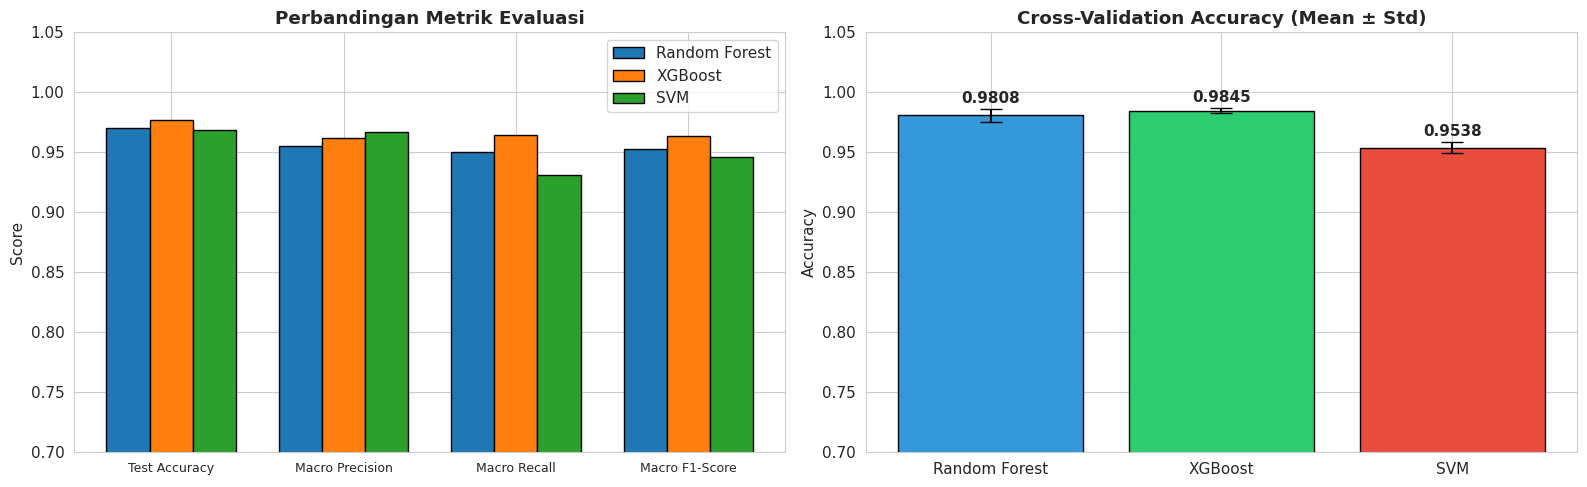

In [ ]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Bar chart: metrik utama ---
metrics_to_plot = ['Test Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, row in comparison_df.iterrows():
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, vals, width, label=row['Model'], edgecolor='black')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.7, 1.05)
axes[0].set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
axes[0].legend()

# --- Bar chart: CV accuracy dengan error bar ---
model_names = comparison_df['Model']
cv_means = comparison_df['CV Mean Accuracy']
cv_stds = comparison_df['CV Std']

bars = axes[1].bar(model_names, cv_means, yerr=cv_stds, capsize=8,
                    color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.7, 1.05)
axes[1].set_title('Cross-Validation Accuracy (Mean ± Std)', fontweight='bold')
for bar, mean, std in zip(bars, cv_means, cv_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                 f'{mean:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.6 Perbandingan Model Setelah Diterapkan Teknik SMOTE (Khusus Data yang *Imbalance*)

Distribusi kelas target ISPU bersifat **tidak seimbang (*imbalanced*)**, di mana kategori "Baik" dan "Sedang" mendominasi sementara kategori "Tidak Sehat" relatif sedikit. Ketidakseimbangan ini dapat membuat model bias terhadap kelas mayoritas.

**SMOTE (*Synthetic Minority Over-sampling Technique*)** mengatasi hal ini dengan membuat sampel sintetis pada kelas minoritas. Penting: SMOTE **hanya diterapkan pada data latih (*training set*)** agar data uji tetap mencerminkan distribusi asli dan evaluasi tidak bias (*data leakage* dihindari).

Pada bagian ini, model di-*retrain* menggunakan data hasil SMOTE, lalu akurasi & metrik **sebelum vs sesudah** SMOTE dibandingkan.


PERBANDINGAN: SEBELUM vs SESUDAH SMOTE


,Model,Kondisi,Test Accuracy,Macro Precision,Macro Recall,CV Mean Accuracy,CV Std
0,Random Forest,Sebelum SMOTE,0.9706,0.9550,0.9506,0.9808,0.0054
1,Random Forest,Sesudah SMOTE,0.9771,0.9566,0.9719,0.9905,0.0029
2,SVM,Sebelum SMOTE,0.9690,0.9666,0.9315,0.9538,0.0044
3,SVM,Sesudah SMOTE,0.9052,0.8152,0.9304,0.9487,0.0059
4,XGBoost,Sebelum SMOTE,0.9771,0.9623,0.9645,0.9845,0.0021
5,XGBoost,Sesudah SMOTE,0.9722,0.9413,0.9772,0.9919,0.0021


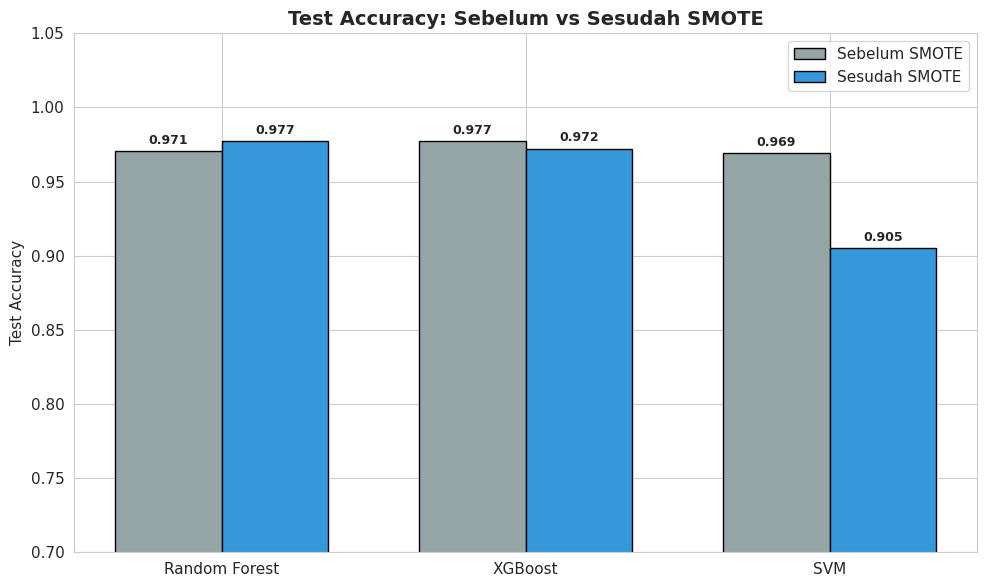

In [ ]:
# ============================================================
# 5.6.2 TABEL PERBANDINGAN SEBELUM vs SESUDAH SMOTE (Tanpa F1-Score)
# ============================================================
cv_smote_configs = {
    'Random Forest': (rf_smote, X_train_smote, y_train_smote),
    'XGBoost': (xgb_smote, X_train_smote, y_train_smote),
    'SVM': (svm_smote, X_train_smote_scaled, y_train_smote)
}

# Tabel performa SESUDAH SMOTE (Macro F1-Score dihapus)
comparison_smote = []
for name, y_pred in predictions_smote.items():
    report = classification_report(y_test, y_pred, output_dict=True, digits=4)
    model, X_cv, y_cv = cv_smote_configs[name]
    cv_scores = cross_val_score(model, X_cv, y_cv, cv=skf, scoring='accuracy')
    comparison_smote.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
comparison_smote_df = pd.DataFrame(comparison_smote).round(4)



# Tabel gabungan SEBELUM vs SESUDAH (Memastikan F1-Score juga dihapus dari data 'Sebelum')
before = comparison_df.drop(columns=['Macro F1-Score'], errors='ignore').copy()
before.insert(1, 'Kondisi', 'Sebelum SMOTE')

after  = comparison_smote_df.copy()
after.insert(1, 'Kondisi', 'Sesudah SMOTE')

combined_df = pd.concat([before, after], ignore_index=True).sort_values(['Model', 'Kondisi']).reset_index(drop=True)
print('\n' + '='*90)
print('PERBANDINGAN: SEBELUM vs SESUDAH SMOTE')
print('='*90)
display(combined_df)

# Visualisasi TUNGGAL: Hanya Test Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
model_names = comparison_df['Model'].tolist()
x = np.arange(len(model_names))
width = 0.35

metric = 'Test Accuracy'
color = '#3498db'

vb = comparison_df.set_index('Model').loc[model_names, metric].values
va = comparison_smote_df.set_index('Model').loc[model_names, metric].values

# Membuat bar chart sebelum vs sesudah
ax.bar(x - width/2, vb, width, label='Sebelum SMOTE', color='#95a5a6', edgecolor='black')
ax.bar(x + width/2, va, width, label='Sesudah SMOTE', color=color, edgecolor='black')

# Pengaturan posisi & label chart
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel(metric)
ax.set_ylim(0.7, 1.05)
ax.set_title(f'{metric}: Sebelum vs Sesudah SMOTE', fontweight='bold', fontsize=14)
ax.legend()

# Menampilkan nilai di atas bar
for xi, (b, a) in enumerate(zip(vb, va)):
    ax.text(xi - width/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(xi + width/2, a + 0.005, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## **6. Deployment**

### 6.1 Simpan Model, Encoder, dan Scaler

In [ ]:
# Simpan semua model terbaik
joblib.dump(rf_best, 'model_random_forest.pkl')
joblib.dump(xgb_best, 'model_xgboost.pkl')
joblib.dump(svm_best, 'model_svm.pkl')

# Simpan encoder dan scaler
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

# Simpan info fitur
joblib.dump(fitur_polutan, 'fitur_polutan.pkl')

print('Model, encoder, dan scaler berhasil disimpan!')
print('\nFile yang disimpan:')
print('  - model_random_forest.pkl')
print('  - model_xgboost.pkl')
print('  - model_svm.pkl')
print('  - label_encoder.pkl')
print('  - standard_scaler.pkl')
print('  - fitur_polutan.pkl')

Model, encoder, dan scaler berhasil disimpan!

File yang disimpan:
  - model_random_forest.pkl
  - model_xgboost.pkl
  - model_svm.pkl
  - label_encoder.pkl
  - standard_scaler.pkl
  - fitur_polutan.pkl


### 6.2 Uji Prediksi dengan Data Baru

In [ ]:
# ============================================================
# SIMULASI PREDIKSI DATA BARU
# ============================================================

# Contoh data baru (6 parameter polutan)
data_baru = pd.DataFrame({
    'pm_sepuluh': [45, 120, 15],
    'pm_duakomalima': [60, 180, 10],
    'sulfur_dioksida': [40, 80, 20],
    'karbon_monoksida': [8, 25, 3],
    'ozon': [10, 50, 5],
    'nitrogen_dioksida': [55, 150, 20]
})

print('Data Baru yang Akan Diprediksi:')
display(data_baru)

# Load model (simulasi)
model_rf = joblib.load('model_random_forest.pkl')
model_xgb = joblib.load('model_xgboost.pkl')
model_svm = joblib.load('model_svm.pkl')
le_loaded = joblib.load('label_encoder.pkl')
scaler_loaded = joblib.load('standard_scaler.pkl')

# Prediksi
print('\n--- Hasil Prediksi ---')

# Random Forest
pred_rf = le_loaded.inverse_transform(model_rf.predict(data_baru))
print(f'Random Forest : {pred_rf}')

# XGBoost
pred_xgb = le_loaded.inverse_transform(model_xgb.predict(data_baru))
print(f'XGBoost       : {pred_xgb}')

# SVM (perlu scaling)
data_baru_scaled = scaler_loaded.transform(data_baru)
pred_svm = le_loaded.inverse_transform(model_svm.predict(data_baru_scaled))
print(f'SVM           : {pred_svm}')

Data Baru yang Akan Diprediksi:


,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida
0,45,60,40,8,10,55
1,120,180,80,25,50,150
2,15,10,20,3,5,20



--- Hasil Prediksi ---
Random Forest : ['SEDANG' 'TIDAK SEHAT' 'BAIK']
XGBoost       : ['SEDANG' 'TIDAK SEHAT' 'BAIK']
SVM           : ['SEDANG' 'TIDAK SEHAT' 'BAIK']


### 6.3 Fungsi Prediksi untuk Integrasi Dashboard

In [ ]:
def prediksi_ispu(pm10, pm25, so2, co, o3, no2, model_choice='random_forest'):
    """
    Fungsi prediksi kategori ISPU untuk integrasi ke sistem web.

    Parameters:
    -----------
    pm10   : float - Nilai PM10
    pm25   : float - Nilai PM2.5
    so2    : float - Nilai SO2
    co     : float - Nilai CO
    o3     : float - Nilai O3
    no2    : float - Nilai NO2
    model_choice : str - 'random_forest', 'xgboost', atau 'svm'

    Returns:
    --------
    str : Kategori ISPU (BAIK / SEDANG / TIDAK SEHAT)
    """
    # Susun input
    input_data = pd.DataFrame([{
        'pm_sepuluh': pm10,
        'pm_duakomalima': pm25,
        'sulfur_dioksida': so2,
        'karbon_monoksida': co,
        'ozon': o3,
        'nitrogen_dioksida': no2
    }])

    # Load model & encoder
    le_deploy = joblib.load('label_encoder.pkl')

    if model_choice == 'random_forest':
        model = joblib.load('model_random_forest.pkl')
        pred = model.predict(input_data)
    elif model_choice == 'xgboost':
        model = joblib.load('model_xgboost.pkl')
        pred = model.predict(input_data)
    elif model_choice == 'svm':
        model = joblib.load('model_svm.pkl')
        scaler_deploy = joblib.load('standard_scaler.pkl')
        input_data = scaler_deploy.transform(input_data)
        pred = model.predict(input_data)
    else:
        raise ValueError("model_choice harus 'random_forest', 'xgboost', atau 'svm'")

    return le_deploy.inverse_transform(pred)[0]

# Contoh penggunaan
hasil = prediksi_ispu(pm10=55, pm25=70, so2=45, co=10, o3=12, no2=65,
                       model_choice='random_forest')
print(f'Prediksi Kategori ISPU: {hasil}')

Prediksi Kategori ISPU: SEDANG


### 6.4 Download Model (di Colab)

In [ ]:
# ============================================================
# EXPORT SEMUA VISUALISASI KE FORMAT JPG
# ============================================================
import os
from google.colab import files

os.makedirs('hasil_visualisasi', exist_ok=True)
dpi = 200

# --- 1. Distribusi Kelas Target ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = df['kategori'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Kelas Target (Kategori ISPU)', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(val), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')
plt.tight_layout()
fig.savefig('hasil_visualisasi/01_distribusi_kelas_target.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 01_distribusi_kelas_target.jpg')

# --- 2. Histogram Distribusi Fitur ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()
for i, col in enumerate(fitur_polutan):
    axes_flat[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes_flat[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes_flat[i].set_xlabel(col)
    axes_flat[i].set_ylabel('Frekuensi')
    mean_val = df[col].mean()
    med_val = df[col].median()
    axes_flat[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.1f}')
    axes_flat[i].axvline(med_val, color='green', linestyle='-', label=f'Median={med_val:.1f}')
    axes_flat[i].legend(fontsize=8)
plt.suptitle('Histogram Distribusi Setiap Parameter Polutan', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('hasil_visualisasi/02_histogram_distribusi.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 02_histogram_distribusi.jpg')

# --- 3. Boxplot Setelah Cleaning ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()
for i, col in enumerate(fitur_polutan):
    sns.boxplot(y=df[col], ax=axes_flat[i], color='lightgreen',
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    axes_flat[i].set_title(f'Boxplot {col}', fontweight='bold')
plt.suptitle('Boxplot Parameter Polutan (Setelah Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('hasil_visualisasi/03_boxplot_setelah_cleaning.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 03_boxplot_setelah_cleaning.jpg')

# --- 4. Heatmap Korelasi ---
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[fitur_polutan].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Heatmap Korelasi Antar Parameter Polutan', fontweight='bold')
plt.tight_layout()
fig.savefig('hasil_visualisasi/04_heatmap_korelasi.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 04_heatmap_korelasi.jpg')

# --- 5. Missing Values ---
fig, ax = plt.subplots(figsize=(10, 4))
missing = df_eda[fitur_polutan].isnull().sum()
bars = ax.bar(missing.index, missing.values, color='salmon', edgecolor='black')
ax.set_title('Jumlah Missing Values per Fitur Polutan', fontweight='bold')
ax.set_ylabel('Jumlah Missing')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontweight='bold')
plt.xticks(rotation=25)
plt.tight_layout()
fig.savefig('hasil_visualisasi/05_missing_values.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 05_missing_values.jpg')

# --- 6. Confusion Matrix ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix\n{name}', fontweight='bold')
plt.tight_layout()
fig.savefig('hasil_visualisasi/06_confusion_matrix.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 06_confusion_matrix.jpg')

# --- 7. Cross-Validation per Fold ---
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = pd.DataFrame(cv_results)
cv_data.index = [f'Fold {i+1}' for i in range(5)]
cv_data.plot(kind='bar', ax=ax, edgecolor='black', width=0.7)
ax.set_title('Cross-Validation Accuracy per Fold', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig('hasil_visualisasi/07_cross_validation.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 07_cross_validation.jpg')

# --- 8. Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, (name, model) in enumerate([('Random Forest', rf_best), ('XGBoost', xgb_best)]):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=fitur_polutan).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Feature Importance - {name}', fontweight='bold')
    axes[i].set_xlabel('Importance')
    for j, (val, label) in enumerate(zip(feat_imp.values, feat_imp.index)):
        axes[i].text(val + 0.005, j, f'{val:.4f}', va='center')
plt.tight_layout()
fig.savefig('hasil_visualisasi/08_feature_importance.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 08_feature_importance.jpg')

# --- 9. Perbandingan Performa Model ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
metrics_to_plot = ['Test Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, row in comparison_df.iterrows():
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, vals, width, label=row['Model'], edgecolor='black')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.7, 1.05)
axes[0].set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
axes[0].legend()
model_names = comparison_df['Model']
cv_means = comparison_df['CV Mean Accuracy']
cv_stds = comparison_df['CV Std']
bars = axes[1].bar(model_names, cv_means, yerr=cv_stds, capsize=8,
                    color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.7, 1.05)
axes[1].set_title('Cross-Validation Accuracy (Mean ± Std)', fontweight='bold')
for bar, mean, std in zip(bars, cv_means, cv_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                 f'{mean:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig('hasil_visualisasi/09_perbandingan_performa.jpg', dpi=dpi, bbox_inches='tight')
plt.close()
print('Saved: 09_perbandingan_performa.jpg')

# ============================================================
# DOWNLOAD SEMUA JPG SEBAGAI ZIP
# ============================================================
import shutil
shutil.make_archive('hasil_visualisasi_ISPU', 'zip', '.', 'hasil_visualisasi')
files.download('hasil_visualisasi_ISPU.zip')
print('\nSemua visualisasi telah di-download sebagai hasil_visualisasi_ISPU.zip')

Saved: 01_distribusi_kelas_target.jpg
Saved: 02_histogram_distribusi.jpg
Saved: 03_boxplot_setelah_cleaning.jpg
Saved: 04_heatmap_korelasi.jpg
Saved: 05_missing_values.jpg
Saved: 06_confusion_matrix.jpg
Saved: 07_cross_validation.jpg
Saved: 08_feature_importance.jpg
Saved: 09_perbandingan_performa.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Semua visualisasi telah di-download sebagai hasil_visualisasi_ISPU.zip


---
## **Ringkasan Hasil**

In [ ]:
print('='*70)
print('RINGKASAN HASIL PENELITIAN')
print('='*70)
print(f'\nDataset    : Data ISPU DKI Jakarta')
print(f'Baris awal : {df_raw.shape[0]}')
print(f'Baris final: {df.shape[0]} (setelah cleaning & outlier removal)')
print(f'Fitur (X)  : {fitur_polutan}')
print(f'Target (y) : kategori → {list(le.classes_)}')
print(f'Split      : 80% train / 20% test (stratified)')
print()
print('Performa Model (setelah tuning):')
print(comparison_df.to_string(index=False))
print()
print(f'MODEL TERBAIK: {best_model_name} (Accuracy: {best_accuracy:.4f})')
print('='*70)

RINGKASAN HASIL PENELITIAN

Dataset    : Data ISPU DKI Jakarta
Baris awal : 3350
Baris final: 3057 (setelah cleaning & outlier removal)
Fitur (X)  : ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida', 'karbon_monoksida', 'ozon', 'nitrogen_dioksida']
Target (y) : kategori → ['BAIK', 'SEDANG', 'TIDAK SEHAT']
Split      : 80% train / 20% test (stratified)

Performa Model (setelah tuning):
        Model  Test Accuracy  Macro Precision  Macro Recall  Macro F1-Score  CV Mean Accuracy  CV Std
Random Forest         0.9706           0.9550        0.9506          0.9527            0.9808  0.0054
      XGBoost         0.9771           0.9623        0.9645          0.9634            0.9845  0.0021
          SVM         0.9690           0.9666        0.9315          0.9457            0.9538  0.0044

MODEL TERBAIK: XGBoost (Accuracy: 0.9771)
